In [15]:
import warnings
warnings.simplefilter("ignore")

import cv2
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
import os
from keras.layers import Input, Dense, Conv2D, MaxPooling2D, Flatten
from scipy.signal import convolve2d

In [16]:
path = "/kaggle/input/datasets/shobhit18th/indian-currency-notes/indian_currency_new"
train_dir = "/kaggle/input/datasets/shobhit18th/indian-currency-notes/indian_currency_new/training"
val_dir = "/kaggle/input/datasets/shobhit18th/indian-currency-notes/indian_currency_new/validation"

train_img = os.listdir(train_dir)
val_img = os.listdir(val_dir)

print("train images", train_img)
print("val images", val_img)

train images ['50', '10', '20', '200', 'Background', '500', '2000', '100']
val images ['50', '10', '20', '200', 'Background', '500', '2000', '100']


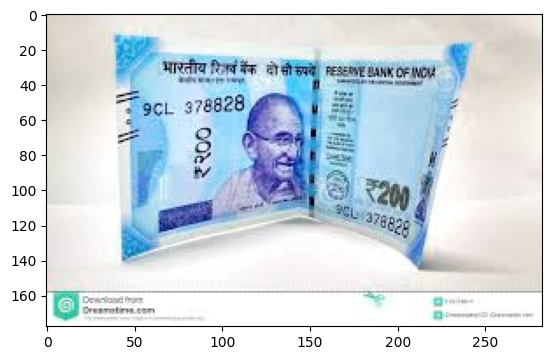

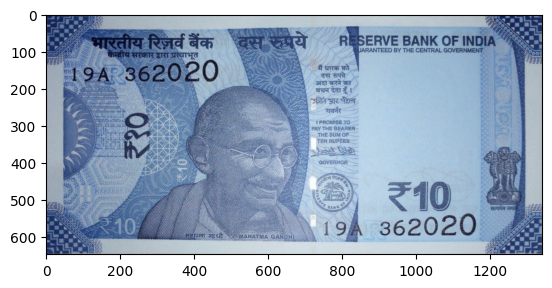

In [17]:
img1 = cv2.imread(train_dir + "/200/" + os.listdir(train_dir + "/200")[0])
img2 = cv2.imread(val_dir + "/10/" + os.listdir(val_dir + "/10")[0])

plt.imshow(img1)
plt.show()

plt.imshow(img2)
plt.show()

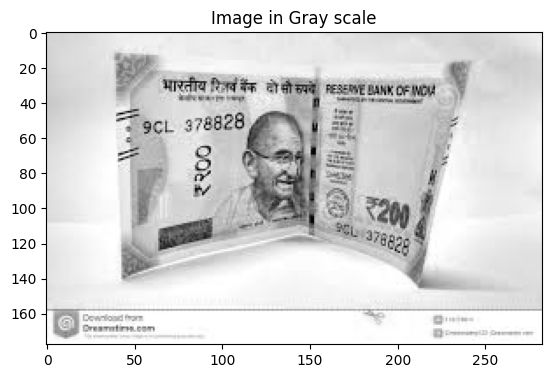

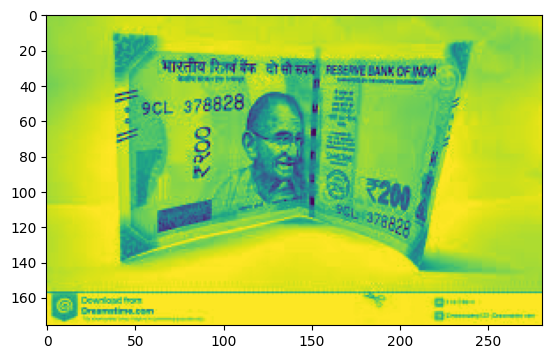

In [18]:
kernel = np.array([[0,0,0],[0,1,0],[0,0,0]])
img1_grayscale = cv2.cvtColor(img1, cv2.COLOR_RGB2GRAY)
conv_img = convolve2d(img1_grayscale, kernel, mode="valid")

plt.imshow(img1_grayscale, cmap='gray')
plt.title("Image in Gray scale")
plt.show()

plt.imshow(conv_img)
plt.show()

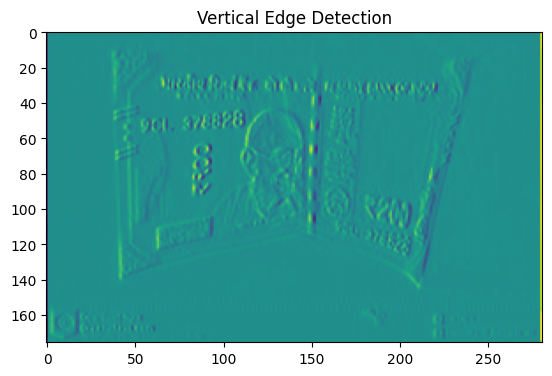

In [19]:
sobel_x = np.array([[-1,0,1],[-2,0,2],[-1,0,1]])
img1_ed_x = convolve2d(conv_img, sobel_x, mode="same")

plt.imshow(img1_ed_x)
plt.title("Vertical Edge Detection")
plt.show()

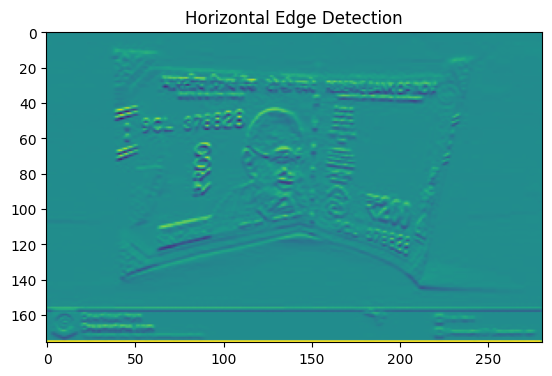

In [20]:
sobel_y = np.array([[-1,-2,-1],[0,0,0],[1,2,1]])
img1_ed_y = convolve2d(conv_img, sobel_y, mode="same")

plt.imshow(img1_ed_y)
plt.title("Horizontal Edge Detection")
plt.show()

In [21]:
img_tr = keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(64, 64),
    batch_size=32,
    labels="inferred",
    label_mode="int"
)

img_val = keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=(64, 64),
    batch_size=32,
    labels="inferred",
    label_mode="int"
)

Found 804 files belonging to 8 classes.
Found 191 files belonging to 8 classes.


In [22]:
input_layer = Input(shape=(64,64,3))
conv1 = Conv2D(32,(3,3), activation="relu")(input_layer)
maxpool1 = MaxPooling2D((2,2))(conv1)
conv2 = Conv2D(64,(3,3), activation="relu")(maxpool1)
maxpool2 = MaxPooling2D((2,2))(conv2)
conv3 = Conv2D(128,(3,3), activation="relu")(maxpool2)
maxpool3 = MaxPooling2D((2,2))(conv3)
conv4 = Conv2D(256,(3,3), activation="relu")(maxpool3)
maxpool4 = MaxPooling2D((2,2))(conv4)
flatten_layer = Flatten()(maxpool4)
dense1 = Dense(128, activation="relu")(flatten_layer)
dense2 = Dense(64, activation="relu")(dense1)
output_layer = Dense(8, activation="softmax")(dense2)

cnn_model = keras.Model(inputs=input_layer, outputs=output_layer)
cnn_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 8)              │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 528,392 (2.02 MB)

 Trainable params: 528,392 (2.02 MB)

 Non-trainable params: 0 (0.00 B)

In [23]:
cnn_model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
es = keras.callbacks.EarlyStopping(monitor="loss", patience=3, verbose=1)
cnn_model.fit(img_tr, validation_data=img_val, epochs=50, callbacks=[es])

Epoch 1/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 10s 302ms/step - accuracy: 0.1973 - loss: 12.3697 - val_accuracy: 0.2304 - val_loss: 2.0328
Epoch 2/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 7s 274ms/step - accuracy: 0.3617 - loss: 1.7506 - val_accuracy: 0.3979 - val_loss: 1.5046
Epoch 3/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 8s 287ms/step - accuracy: 0.5218 - loss: 1.3317 - val_accuracy: 0.5236 - val_loss: 1.2308
Epoch 4/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 7s 280ms/step - accuracy: 0.5038 - loss: 1.3584 - val_accuracy: 0.3351 - val_loss: 1.8725
Epoch 5/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 7s 277ms/step - accuracy: 0.5095 - loss: 1.3405 - val_accuracy: 0.6911 - val_loss: 0.9653
Epoch 6/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 7s 285ms/step - accuracy: 0.6930 - loss: 0.8243 - val_accuracy: 0.7173 - val_loss: 0.8082
Epoch 7/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 8s 285ms/step - accuracy: 0.7342 - loss: 0.7127 - val_accuracy: 0.7330 - val_loss: 0.7965
Epoch 8/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 7s 276ms/step - accuracy: 0.7406 - loss: 0.7598 - val_accuracy: 

In [24]:
train_pred = cnn_model.predict(img_tr)
val_pred = cnn_model.predict(img_val)

train_pred_classes = np.argmax(train_pred, axis=1)
val_pred_classes = np.argmax(val_pred, axis=1)

26/26 ━━━━━━━━━━━━━━━━━━━━ 4s 153ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 132ms/step


In [25]:
train_loss, train_acc = cnn_model.evaluate(img_tr)
print("Train Accuracy:", train_acc)

val_loss, val_acc = cnn_model.evaluate(img_val)
print("Validation Accuracy:", val_acc)

26/26 ━━━━━━━━━━━━━━━━━━━━ 4s 141ms/step - accuracy: 0.9088 - loss: 0.4384
Train Accuracy: 0.9216417670249939
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 144ms/step - accuracy: 0.8683 - loss: 0.6706
Validation Accuracy: 0.8638743162155151
